## Importamos las Librerías:

In [77]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import classification_report, accuracy_score, balanced_accuracy_score
from imblearn.over_sampling import SMOTE

## Establecemos los Parámetros de los Gráficos:

In [78]:
sns.set_style("white")
sns.set_context("notebook")
plt.rcParams.update({
    'font.family': 'serif',
    'mathtext.fontset': 'stix',
    'font.serif': 'Times New Roman',
    'figure.figsize': (11, 9.4),
    'axes.edgecolor': 'white',
    'axes.labelcolor': '#333333',
    'axes.titlesize': 20,
    'axes.titlecolor': '#333333',
    'xtick.color': '#333333',
    'ytick.color': '#333333',
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12
})

## Cargamos el Conjunto de Datos:

In [79]:
data = pd.read_csv('~/homicidios/data/final/homicidios_final.csv')
data

,ent_regis,ent_resid,tloc_ocurr,causa_def,cod_adicio,lista_mex,sexo,afromex,conindig,lengua,...,area_ur,edad_agru,complicaro,dia_cert,mes_cert,anio_cert,maternas,razon_m,estado_defuncion_registrada,estado_defuncion_residencia
0,1,32,500 000 a 999 999 habitantes,"Neumonía, no especificada",NaN,Neumonía,Mujer,No,No,No,...,Urbana,De 70 a 74 años,No especificada,Dieciocho días,Diciembre,2022,NaN,NaN,Aguascalientes,Zacatecas
1,1,1,500 000 a 999 999 habitantes,Síndrome de dificultad respiratoria del adulto,NaN,Las demás enfermedades del aparato respiratorio,Mujer,No,No,No,...,Urbana,De 75 a 79 años,No especificada,Doce días,Diciembre,2022,NaN,NaN,Aguascalientes,Aguascalientes
2,1,1,500 000 a 999 999 habitantes,Enfermedad pulmonar obstructiva crónica con in...,NaN,Enfermedades pulmonares obstructivas crónicas,Mujer,No,No,No,...,Urbana,De 65 a 69 años,No especificada,Diecisiete días,Diciembre,2022,NaN,NaN,Aguascalientes,Aguascalientes
3,1,1,500 000 a 999 999 habitantes,Desnutrición proteicocalórica leve,NaN,Otras desnutriciones proteinocalóricas,Mujer,No,No,No,...,Urbana,De 90 a 94 años,No especificada,Un día,Enero,2023,NaN,NaN,Aguascalientes,Aguascalientes
4,1,14,500 000 a 999 999 habitantes,Cirrosis hepática alcohólica,NaN,Enfermedad alcohólica del hígado,Hombre,No,No,No,...,Rural,De 45 a 49 años,No aplica,Veintidós días,Diciembre,2022,NaN,NaN,Aguascalientes,Jalisco
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
799864,32,32,20 000 a 29 999 habitantes,"Síndrome de aspiración neonatal, sin otra espe...",NaN,Dificultad respiratoria del recién nacido y ot...,Mujer,No,No,No aplica a menores de 3 años,...,Urbana,Menores de un año,No aplica,No especificado,Diciembre,2023,NaN,NaN,Zacatecas,Zacatecas
799865,32,32,100 000 a 249 999 habitantes,"Kernicterus, no especificado",NaN,Las demás afecciones originadas en el período ...,Mujer,No,No,No aplica a menores de 3 años,...,Urbana,Menores de un año,No aplica,Cinco días,Junio,2023,NaN,NaN,Zacatecas,Zacatecas
799866,32,32,100 000 a 249 999 habitantes,Síndrome de dificultad respiratoria del recién...,NaN,Dificultad respiratoria del recién nacido y ot...,Mujer,No,No,No aplica a menores de 3 años,...,Urbana,Menores de un año,No aplica,Nueve días,Agosto,2023,NaN,NaN,Zacatecas,Zacatecas
799867,32,32,100 000 a 249 999 habitantes,Gastrosquisis,NaN,Otras malformaciones congénitas y deformidades...,Mujer,No,No,No aplica a menores de 3 años,...,Urbana,Menores de un año,No aplica,Diecinueve días,Septiembre,2023,NaN,NaN,Zacatecas,Zacatecas


## Enraizamos el Proyecto:

In [80]:
import sys, os
sys.path.append(os.path.abspath(".."))

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Importamos las Funciones Modulares:

In [81]:
import modules.sustituir_nulos
from modules.sustituir_nulos import sustituir_nulos_pd
from modules.eliminar_variables import eliminar_variables_pd
from modules.eliminar_variables import variables_ml

In [82]:
data = eliminar_variables_pd(df= data, variables= variables_ml)

In [83]:
data.shape

(799869, 48)

## Sustituimos Valores Nulos:

In [84]:
data = sustituir_nulos_pd(df= data, variable= 'lista_mex', text= 'Sin Registros')
data = sustituir_nulos_pd(df= data, variable= 'estado_defuncion_residencia', text= 'Sin Registros')

## Corroboramos Ausencia de Valores Nulos:

In [85]:
data.isnull().sum().sort_values(ascending=False).head(10)

tloc_ocurr    0
causa_def     0
lista_mex     0
sexo          0
afromex       0
conindig      0
lengua        0
cve_lengua    0
nacionalid    0
nacesp_cve    0
dtype: int64

## Reducimos el Conjunto de Datos:

In [86]:
data = data[data['tipo_defun']=='Homicidio (Agresión)']

In [87]:
data['causa_def'].value_counts()

causa_def
Agresión con disparo de otras armas de fuego, y las no especificadas en calles y carreteras        11708
Agresión con disparo de otras armas de fuego, y las no especificadas en lugar no especificado       4431
Agresión con disparo de otras armas de fuego, y las no especificadas en vivienda                    2622
Agresión con disparo de otras armas de fuego, y las no especificadas en otro lugar especificado     2023
Agresión por medios no especificados en lugar no especificado                                       1385
                                                                                                   ...  
Agresión con fuerza corporal en área industrial y de la construcción                                   1
Agresión con plaguicidas en granja                                                                     1
Agresión con objeto romo o sin filo en institución residencial                                         1
Agresión por colisión de vehículo de motor en

## Creamos la Variable Clasificadora:

In [88]:
data['feminmuj'] = ['Sí' if tipo_defun == 'Homicidio (Agresión)' and sexo == 'Mujer' else 'No' 
                          for tipo_defun, sexo in zip(data['tipo_defun'], data['sexo'])]

data

,tloc_ocurr,causa_def,lista_mex,sexo,afromex,conindig,lengua,cve_lengua,nacionalid,nacesp_cve,...,minutos,capitulo,lista1,area_ur,edad_agru,dia_cert,mes_cert,estado_defuncion_registrada,estado_defuncion_residencia,feminmuj
814,500 000 a 999 999 habitantes,Agresión con objeto cortante en lugar no espec...,Agresiones (homicidios),Hombre,No,No,No,No aplica,Mexicana,Mexicana (no especificado de Entidad Federativa),...,Trece minutos,Factores suplementarios relacionados con causa...,Agresiones,Urbana,De 20 a 24 años,Dieciséis días,Enero,Aguascalientes,Aguascalientes,No
847,500 000 a 999 999 habitantes,"Agresión con disparo de otras armas de fuego, ...",Agresiones (homicidios),Hombre,No,No,No,No aplica,Mexicana,Mexicana (no especificado de Entidad Federativa),...,Treinta minutos,Factores suplementarios relacionados con causa...,Agresiones,Urbana,De 25 a 29 años,Siete días,Marzo,Aguascalientes,Aguascalientes,No
888,10 000 a 14 999 habitantes,"Agresión con disparo de otras armas de fuego, ...",Agresiones (homicidios),Mujer,No,No,No,No aplica,Mexicana,Mexicana (no especificado de Entidad Federativa),...,No especificado,Factores suplementarios relacionados con causa...,Agresiones,Urbana,De 15 a 19 años,Veinticuatro días,Marzo,Aguascalientes,Aguascalientes,Sí
889,500 000 a 999 999 habitantes,Agresión con objeto romo o sin filo en calles ...,Agresiones (homicidios),Hombre,No,No,No,No aplica,Mexicana,Mexicana (no especificado de Entidad Federativa),...,Nueve minutos,Factores suplementarios relacionados con causa...,Agresiones,Urbana,De 40 a 44 años,Veintiséis días,Marzo,Aguascalientes,Aguascalientes,No
900,500 000 a 999 999 habitantes,"Agresión con disparo de otras armas de fuego, ...",Agresiones (homicidios),Mujer,No,No,No,No aplica,Mexicana,Mexicana (no especificado de Entidad Federativa),...,No especificado,Factores suplementarios relacionados con causa...,Agresiones,Urbana,De 55 a 59 años,Tres días,Enero,Aguascalientes,Aguascalientes,Sí
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
799848,100 000 a 249 999 habitantes,Agresión con objeto cortante en lugar no espec...,Agresiones (homicidios),Hombre,No,No,Sí,No especificado,Mexicana,Mexicana (no especificado de Entidad Federativa),...,No especificado,Factores suplementarios relacionados con causa...,Agresiones,Rural,De 15 a 19 años,No especificado,Septiembre,Zacatecas,Zacatecas,No
799849,100 000 a 249 999 habitantes,"Agresión con disparo de otras armas de fuego, ...",Agresiones (homicidios),Mujer,No,No,Sí,No especificado,Mexicana,Mexicana (no especificado de Entidad Federativa),...,No especificado,Factores suplementarios relacionados con causa...,Agresiones,Urbana,De 20 a 24 años,Veinticuatro días,Diciembre,Zacatecas,Zacatecas,Sí
799850,100 000 a 249 999 habitantes,"Agresión con disparo de otras armas de fuego, ...",Agresiones (homicidios),Hombre,No,No,Sí,No especificado,Mexicana,Mexicana (no especificado de Entidad Federativa),...,No especificado,Factores suplementarios relacionados con causa...,Agresiones,Urbana,De 20 a 24 años,Veintinueve días,Diciembre,Zacatecas,Zacatecas,No
799851,100 000 a 249 999 habitantes,"Agresión con disparo de otras armas de fuego, ...",Agresiones (homicidios),Hombre,No,No,Sí,No especificado,Mexicana,Mexicana (no especificado de Entidad Federativa),...,No especificado,Factores suplementarios relacionados con causa...,Agresiones,Urbana,De 40 a 44 años,Treinta y un días,Diciembre,Zacatecas,Zacatecas,No


In [89]:
data = data.drop(['tipo_defun', 'lista_mex', 'lista1'], axis=1)
data

,tloc_ocurr,causa_def,sexo,afromex,conindig,lengua,cve_lengua,nacionalid,nacesp_cve,edad,...,horas,minutos,capitulo,area_ur,edad_agru,dia_cert,mes_cert,estado_defuncion_registrada,estado_defuncion_residencia,feminmuj
814,500 000 a 999 999 habitantes,Agresión con objeto cortante en lugar no espec...,Hombre,No,No,No,No aplica,Mexicana,Mexicana (no especificado de Entidad Federativa),Veintiún años,...,Quince horas,Trece minutos,Factores suplementarios relacionados con causa...,Urbana,De 20 a 24 años,Dieciséis días,Enero,Aguascalientes,Aguascalientes,No
847,500 000 a 999 999 habitantes,"Agresión con disparo de otras armas de fuego, ...",Hombre,No,No,No,No aplica,Mexicana,Mexicana (no especificado de Entidad Federativa),Veintiocho años,...,Veintiún horas,Treinta minutos,Factores suplementarios relacionados con causa...,Urbana,De 25 a 29 años,Siete días,Marzo,Aguascalientes,Aguascalientes,No
888,10 000 a 14 999 habitantes,"Agresión con disparo de otras armas de fuego, ...",Mujer,No,No,No,No aplica,Mexicana,Mexicana (no especificado de Entidad Federativa),Dieciocho años,...,No especificada,No especificado,Factores suplementarios relacionados con causa...,Urbana,De 15 a 19 años,Veinticuatro días,Marzo,Aguascalientes,Aguascalientes,Sí
889,500 000 a 999 999 habitantes,Agresión con objeto romo o sin filo en calles ...,Hombre,No,No,No,No aplica,Mexicana,Mexicana (no especificado de Entidad Federativa),Cuarenta años,...,Nueve horas,Nueve minutos,Factores suplementarios relacionados con causa...,Urbana,De 40 a 44 años,Veintiséis días,Marzo,Aguascalientes,Aguascalientes,No
900,500 000 a 999 999 habitantes,"Agresión con disparo de otras armas de fuego, ...",Mujer,No,No,No,No aplica,Mexicana,Mexicana (no especificado de Entidad Federativa),Cincuenta y cinco años,...,No especificada,No especificado,Factores suplementarios relacionados con causa...,Urbana,De 55 a 59 años,Tres días,Enero,Aguascalientes,Aguascalientes,Sí
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
799848,100 000 a 249 999 habitantes,Agresión con objeto cortante en lugar no espec...,Hombre,No,No,Sí,No especificado,Mexicana,Mexicana (no especificado de Entidad Federativa),Dieciocho años,...,No especificada,No especificado,Factores suplementarios relacionados con causa...,Rural,De 15 a 19 años,No especificado,Septiembre,Zacatecas,Zacatecas,No
799849,100 000 a 249 999 habitantes,"Agresión con disparo de otras armas de fuego, ...",Mujer,No,No,Sí,No especificado,Mexicana,Mexicana (no especificado de Entidad Federativa),Veinticuatro años,...,No especificada,No especificado,Factores suplementarios relacionados con causa...,Urbana,De 20 a 24 años,Veinticuatro días,Diciembre,Zacatecas,Zacatecas,Sí
799850,100 000 a 249 999 habitantes,"Agresión con disparo de otras armas de fuego, ...",Hombre,No,No,Sí,No especificado,Mexicana,Mexicana (no especificado de Entidad Federativa),Veinte años,...,No especificada,No especificado,Factores suplementarios relacionados con causa...,Urbana,De 20 a 24 años,Veintinueve días,Diciembre,Zacatecas,Zacatecas,No
799851,100 000 a 249 999 habitantes,"Agresión con disparo de otras armas de fuego, ...",Hombre,No,No,Sí,No especificado,Mexicana,Mexicana (no especificado de Entidad Federativa),Cuarenta años,...,No especificada,No especificado,Factores suplementarios relacionados con causa...,Urbana,De 40 a 44 años,Treinta y un días,Diciembre,Zacatecas,Zacatecas,No


## Convertimos a Numérica la Variable Objetivo:

In [90]:
data['feminmuj'].replace(to_replace='Sí', value = 1, inplace=True)
data['feminmuj'].replace(to_replace='No', value = 0, inplace=True)

In [91]:
data.head()

,tloc_ocurr,causa_def,sexo,afromex,conindig,lengua,cve_lengua,nacionalid,nacesp_cve,edad,...,horas,minutos,capitulo,area_ur,edad_agru,dia_cert,mes_cert,estado_defuncion_registrada,estado_defuncion_residencia,feminmuj
814,500 000 a 999 999 habitantes,Agresión con objeto cortante en lugar no espec...,Hombre,No,No,No,No aplica,Mexicana,Mexicana (no especificado de Entidad Federativa),Veintiún años,...,Quince horas,Trece minutos,Factores suplementarios relacionados con causa...,Urbana,De 20 a 24 años,Dieciséis días,Enero,Aguascalientes,Aguascalientes,0
847,500 000 a 999 999 habitantes,"Agresión con disparo de otras armas de fuego, ...",Hombre,No,No,No,No aplica,Mexicana,Mexicana (no especificado de Entidad Federativa),Veintiocho años,...,Veintiún horas,Treinta minutos,Factores suplementarios relacionados con causa...,Urbana,De 25 a 29 años,Siete días,Marzo,Aguascalientes,Aguascalientes,0
888,10 000 a 14 999 habitantes,"Agresión con disparo de otras armas de fuego, ...",Mujer,No,No,No,No aplica,Mexicana,Mexicana (no especificado de Entidad Federativa),Dieciocho años,...,No especificada,No especificado,Factores suplementarios relacionados con causa...,Urbana,De 15 a 19 años,Veinticuatro días,Marzo,Aguascalientes,Aguascalientes,1
889,500 000 a 999 999 habitantes,Agresión con objeto romo o sin filo en calles ...,Hombre,No,No,No,No aplica,Mexicana,Mexicana (no especificado de Entidad Federativa),Cuarenta años,...,Nueve horas,Nueve minutos,Factores suplementarios relacionados con causa...,Urbana,De 40 a 44 años,Veintiséis días,Marzo,Aguascalientes,Aguascalientes,0
900,500 000 a 999 999 habitantes,"Agresión con disparo de otras armas de fuego, ...",Mujer,No,No,No,No aplica,Mexicana,Mexicana (no especificado de Entidad Federativa),Cincuenta y cinco años,...,No especificada,No especificado,Factores suplementarios relacionados con causa...,Urbana,De 55 a 59 años,Tres días,Enero,Aguascalientes,Aguascalientes,1


In [92]:
data = data[data['sexo'] != 'No especificado']

In [93]:
data.shape

(31983, 46)

## === Reemplazar el undersampling por SMOTE ===:

In [94]:
X = data.drop('sexo', axis=1)
y = data['sexo']

## Codificar variables categóricas antes de aplicar SMOTE:

In [95]:
X = pd.get_dummies(X)

In [96]:
X

,dia_ocurr,mes_ocurr,dia_regis,mes_regis,anio_regis,dia_nacim,anio_nacim,feminmuj,tloc_ocurr_1 000 000 a 1 499 999 habitantes,tloc_ocurr_1 000 a 1 999 habitantes,...,estado_defuncion_residencia_San Luis Potosí,estado_defuncion_residencia_Sin Registros,estado_defuncion_residencia_Sinaloa,estado_defuncion_residencia_Sonora,estado_defuncion_residencia_Tabasco,estado_defuncion_residencia_Tamaulipas,estado_defuncion_residencia_Tlaxcala,estado_defuncion_residencia_Veracruz,estado_defuncion_residencia_Yucatán,estado_defuncion_residencia_Zacatecas
814,15,1,19,1,2023,25,2001,0,False,False,...,False,False,False,False,False,False,False,False,False,False
847,6,3,14,3,2023,18,1994,0,False,False,...,False,False,False,False,False,False,False,False,False,False
888,24,3,99,3,2023,19,2004,1,False,False,...,False,False,False,False,False,False,False,False,False,False
889,25,3,27,3,2023,28,1982,0,False,False,...,False,False,False,False,False,False,False,False,False,False
900,2,1,9,1,2023,12,1967,1,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
799848,1,9,1,9,2023,30,2004,0,False,False,...,False,False,False,False,False,False,False,False,False,True
799849,23,12,23,12,2023,29,1999,1,False,False,...,False,False,False,False,False,False,False,False,False,True
799850,28,12,28,12,2023,8,2003,0,False,False,...,False,False,False,False,False,False,False,False,False,True
799851,29,12,29,12,2023,17,1983,0,False,False,...,False,False,False,False,False,False,False,False,False,True


## Escalar antes de SMOTE (opcional pero recomendable si hay variables continuas):

In [97]:
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

In [98]:
X_scaled

,dia_ocurr,mes_ocurr,dia_regis,mes_regis,anio_regis,dia_nacim,anio_nacim,feminmuj,tloc_ocurr_1 000 000 a 1 499 999 habitantes,tloc_ocurr_1 000 a 1 999 habitantes,...,estado_defuncion_residencia_San Luis Potosí,estado_defuncion_residencia_Sin Registros,estado_defuncion_residencia_Sinaloa,estado_defuncion_residencia_Sonora,estado_defuncion_residencia_Tabasco,estado_defuncion_residencia_Tamaulipas,estado_defuncion_residencia_Tlaxcala,estado_defuncion_residencia_Veracruz,estado_defuncion_residencia_Yucatán,estado_defuncion_residencia_Zacatecas
0,0.142857,0.000000,0.183673,0.000000,0.0,0.244898,0.009167,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.051020,0.020408,0.132653,0.181818,0.0,0.173469,0.008300,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.234694,0.020408,1.000000,0.181818,0.0,0.183673,0.009539,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.244898,0.020408,0.265306,0.181818,0.0,0.275510,0.006814,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.010204,0.000000,0.081633,0.000000,0.0,0.112245,0.004955,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31978,0.000000,0.081633,0.000000,0.727273,0.0,0.295918,0.009539,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
31979,0.224490,0.112245,0.224490,1.000000,0.0,0.285714,0.008920,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
31980,0.275510,0.112245,0.275510,1.000000,0.0,0.071429,0.009415,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
31981,0.285714,0.112245,0.285714,1.000000,0.0,0.163265,0.006938,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


## Aplicar SMOTE:

In [99]:
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_scaled, y)

## Copia del dataset para procesamiento posterior:

In [100]:
df_data_processing = X_resampled.copy()
df_data_processing['sexo'] = y_resampled

# Asegúrate de aplicar one-hot encoding correctamente
df_data_processing = pd.get_dummies(df_data_processing)

In [101]:
df_data_processing

,dia_ocurr,mes_ocurr,dia_regis,mes_regis,anio_regis,dia_nacim,anio_nacim,feminmuj,tloc_ocurr_1 000 000 a 1 499 999 habitantes,tloc_ocurr_1 000 a 1 999 habitantes,...,estado_defuncion_residencia_Sinaloa,estado_defuncion_residencia_Sonora,estado_defuncion_residencia_Tabasco,estado_defuncion_residencia_Tamaulipas,estado_defuncion_residencia_Tlaxcala,estado_defuncion_residencia_Veracruz,estado_defuncion_residencia_Yucatán,estado_defuncion_residencia_Zacatecas,sexo_Hombre,sexo_Mujer
0,0.142857,0.000000,0.183673,0.000000,0.0,0.244898,0.009167,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,True,False
1,0.051020,0.020408,0.132653,0.181818,0.0,0.173469,0.008300,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,True,False
2,0.234694,0.020408,1.000000,0.181818,0.0,0.183673,0.009539,1.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,False,True
3,0.244898,0.020408,0.265306,0.181818,0.0,0.275510,0.006814,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,True,False
4,0.010204,0.000000,0.081633,0.000000,0.0,0.112245,0.004955,1.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56483,0.201298,0.091837,0.201298,0.818182,0.0,1.000000,1.000000,1.0,0.000000,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,False,True
56484,0.162945,0.061224,0.162945,0.545455,0.0,1.000000,1.000000,1.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,False,True
56485,0.059249,0.049192,1.000000,0.438254,0.0,0.109355,0.003848,1.0,0.089603,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,False,True
56486,0.230273,0.027183,0.623320,0.276774,0.0,0.167603,0.008424,1.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,False,True


In [102]:
df_data_processing = df_data_processing.drop(['sexo_Hombre', 'sexo_Mujer'], axis=1)
df_data_processing

,dia_ocurr,mes_ocurr,dia_regis,mes_regis,anio_regis,dia_nacim,anio_nacim,feminmuj,tloc_ocurr_1 000 000 a 1 499 999 habitantes,tloc_ocurr_1 000 a 1 999 habitantes,...,estado_defuncion_residencia_San Luis Potosí,estado_defuncion_residencia_Sin Registros,estado_defuncion_residencia_Sinaloa,estado_defuncion_residencia_Sonora,estado_defuncion_residencia_Tabasco,estado_defuncion_residencia_Tamaulipas,estado_defuncion_residencia_Tlaxcala,estado_defuncion_residencia_Veracruz,estado_defuncion_residencia_Yucatán,estado_defuncion_residencia_Zacatecas
0,0.142857,0.000000,0.183673,0.000000,0.0,0.244898,0.009167,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.051020,0.020408,0.132653,0.181818,0.0,0.173469,0.008300,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.234694,0.020408,1.000000,0.181818,0.0,0.183673,0.009539,1.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.244898,0.020408,0.265306,0.181818,0.0,0.275510,0.006814,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.010204,0.000000,0.081633,0.000000,0.0,0.112245,0.004955,1.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56483,0.201298,0.091837,0.201298,0.818182,0.0,1.000000,1.000000,1.0,0.000000,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
56484,0.162945,0.061224,0.162945,0.545455,0.0,1.000000,1.000000,1.0,0.000000,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
56485,0.059249,0.049192,1.000000,0.438254,0.0,0.109355,0.003848,1.0,0.089603,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
56486,0.230273,0.027183,0.623320,0.276774,0.0,0.167603,0.008424,1.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Separar Variables Predictoras y Objetivo:

In [103]:
X = df_data_processing.drop('feminmuj', axis=1)
y = df_data_processing['feminmuj'].values

## === División del conjunto de datos ===:

In [104]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

## === Modelo de Regresión Logística con pesos balanceados ===:

In [105]:
model = LogisticRegression(class_weight='balanced', max_iter=1000)
result = model.fit(X_train, y_train)

## === Evaluación del modelo ===:

In [106]:
prediction_test = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, prediction_test))
print("Balanced Accuracy:", balanced_accuracy_score(y_test, prediction_test))
print(classification_report(y_test, prediction_test))

Accuracy: 0.7560630200035404
Balanced Accuracy: 0.7560630200035404
              precision    recall  f1-score   support

         0.0       0.78      0.71      0.74      5649
         1.0       0.73      0.80      0.77      5649

    accuracy                           0.76     11298
   macro avg       0.76      0.76      0.76     11298
weighted avg       0.76      0.76      0.76     11298



Axes(0.125,0.11;0.775x0.77)


Text(0.5, 1.0, 'Variables que más influyen en que un Homicidio Registrado en México sea de Mujer')

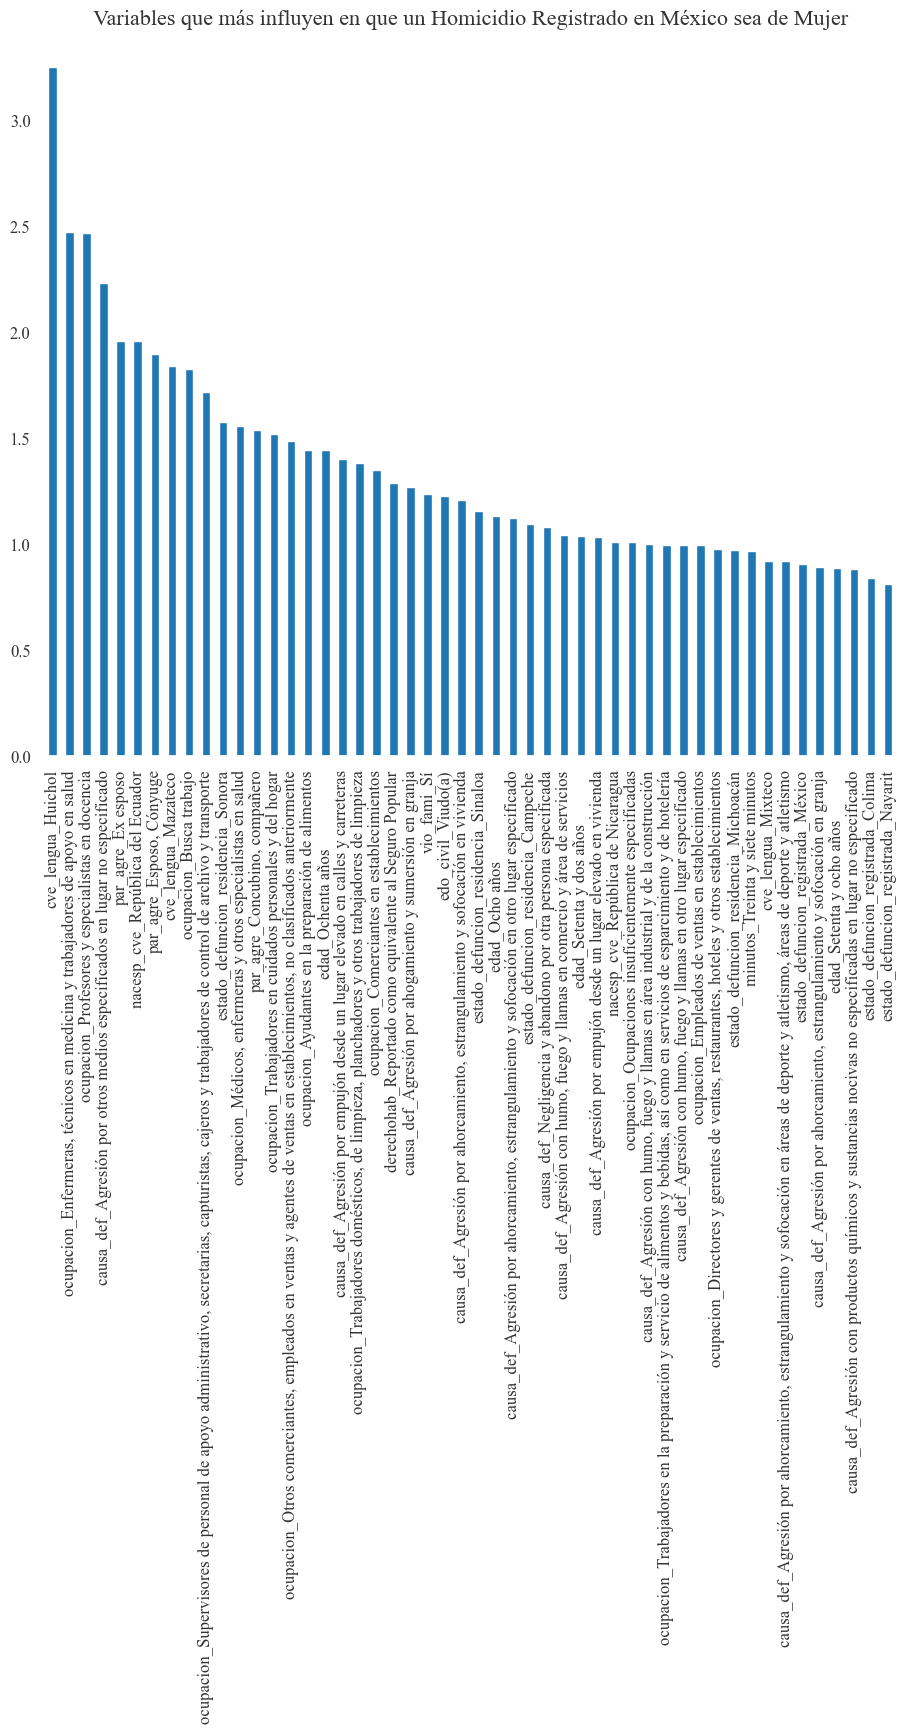

In [107]:
weights = pd.Series(model.coef_[0],
                    index=X.columns.values) 
print(weights.sort_values(ascending=False)[0:50].plot(kind='bar'))
plt.title('Variables que más influyen en que un Homicidio Registrado en México sea de Mujer', size = 16)

Axes(0.125,0.11;0.775x0.77)


Text(0.5, 1.0, 'Variables que menos influyen en que un Homicidio Registrado en México sea de Mujer')

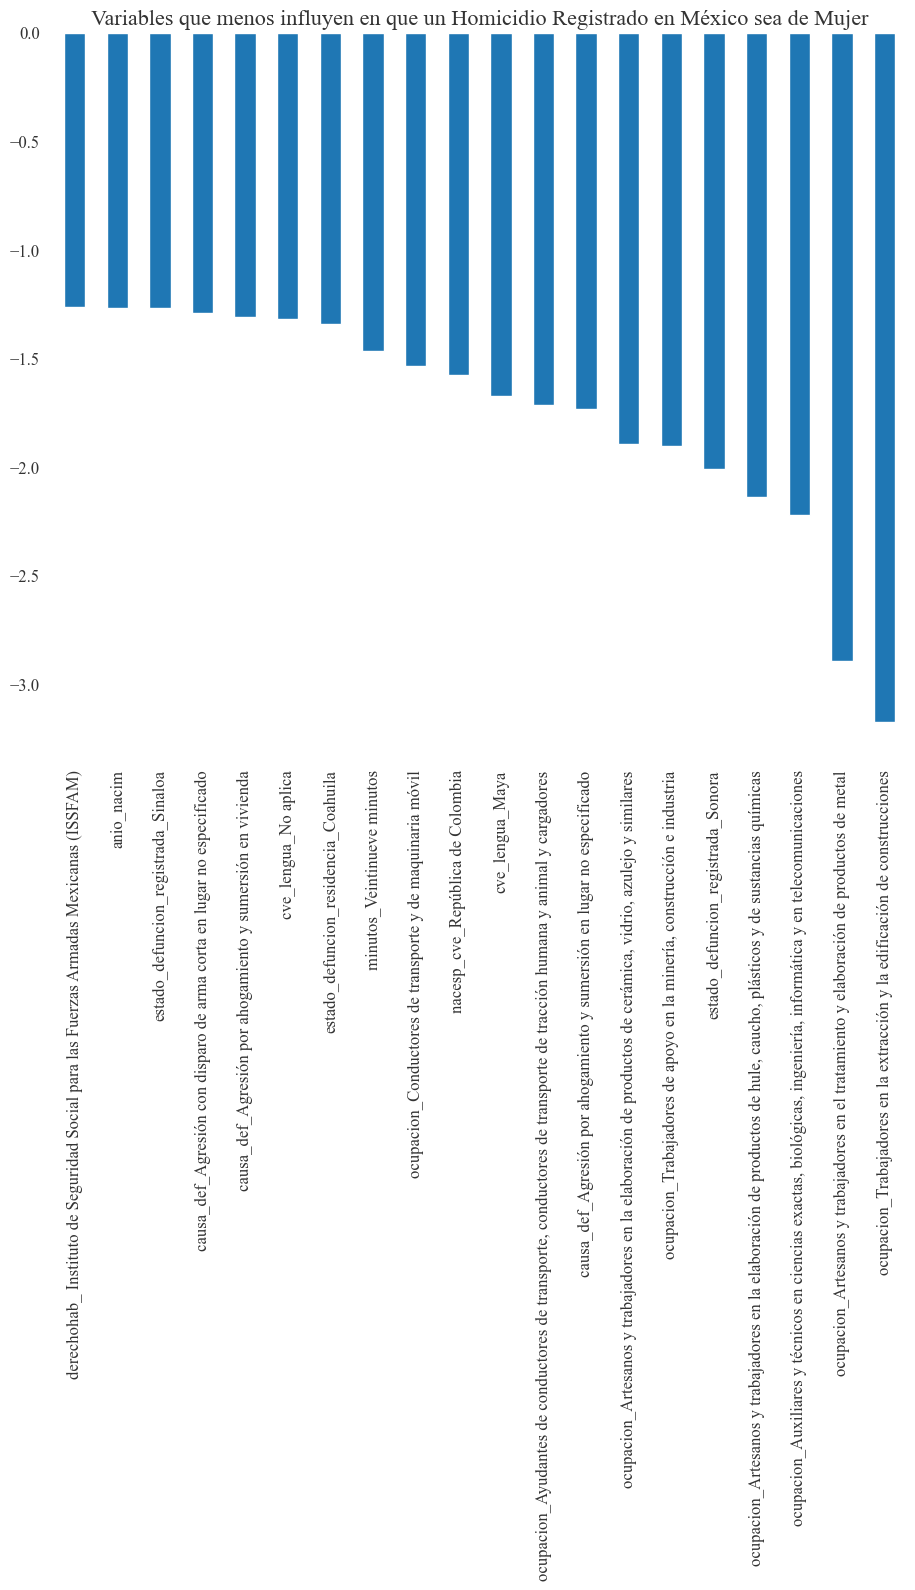

In [108]:
print(weights.sort_values(ascending=False)[-20:].plot(kind='bar'))
plt.title('Variables que menos influyen en que un Homicidio Registrado en México sea de Mujer', size = 16)

## Matriz de Confusión:

In [109]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

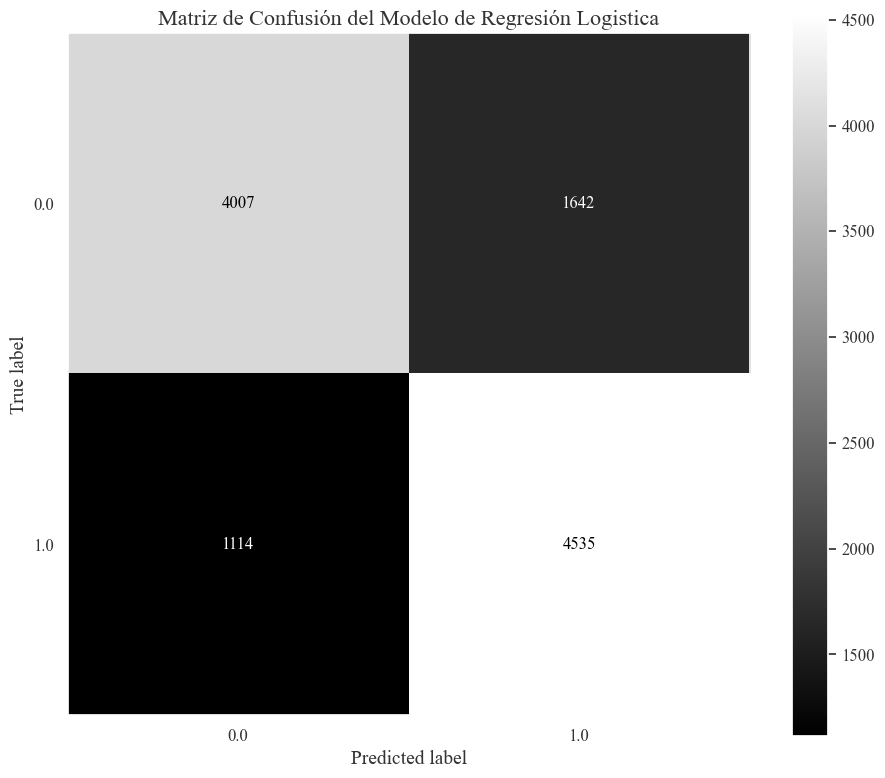

In [110]:
cm = confusion_matrix(y_test, prediction_test, labels=model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels=model.classes_)
disp.plot(cmap='gray')
plt.title('Matriz de Confusión del Modelo de Regresión Logistica', size = 16)
plt.show()

In [111]:
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, classification_report
import numpy as np

## Definimos el Modelo:

# Inicializar validación cruzada estratificada:

In [112]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

## Almacenar resultados:

In [113]:
accuracy_scores = []
balanced_acc_scores = []
f1_scores = []

for train_index, test_index in skf.split(X, y):
    X_train_fold, X_test_fold = X.iloc[train_index], X.iloc[test_index]
    y_train_fold, y_test_fold = y[train_index], y[test_index]
    
    model.fit(X_train_fold, y_train_fold)
    y_pred_fold = model.predict(X_test_fold)
    
    accuracy_scores.append(accuracy_score(y_test_fold, y_pred_fold))
    balanced_acc_scores.append(balanced_accuracy_score(y_test_fold, y_pred_fold))
    f1_scores.append(f1_score(y_test_fold, y_pred_fold))

## Mostrar resultados promedio:

In [114]:
print("===== Validación Cruzada (5-fold) =====")
print(f"Accuracy promedio: {np.mean(accuracy_scores):.4f}")
print(f"Balanced Accuracy promedio: {np.mean(balanced_acc_scores):.4f}")
print(f"F1-score promedio: {np.mean(f1_scores):.4f}")

===== Validación Cruzada (5-fold) =====
Accuracy promedio: 0.7505
Balanced Accuracy promedio: 0.7505
F1-score promedio: 0.7610


## Coeficientes:

In [115]:
feature_names = X.columns 

coefficients = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': model.coef_[0]
})

coefficients['Abs_Coefficient'] = abs(coefficients['Coefficient'])
coefficients = coefficients.sort_values(by='Abs_Coefficient', ascending=False)

print("\nCoeficientes del Modelo de Regresión Logística:")


Coeficientes del Modelo de Regresión Logística:


In [116]:
coefficients.sort_values(by='Coefficient', ascending=False).head(20)

,Feature,Coefficient,Abs_Coefficient
162,cve_lengua_Huichol,3.024723,3.024723
131,causa_def_Agresión por otros medios especifica...,2.886421,2.886421
381,"ocupacion_Enfermeras, técnicos en medicina y t...",2.537195,2.537195
400,ocupacion_Profesores y especialistas en docencia,2.438986,2.438986
459,par_agre_Ex esposo,2.216565,2.216565
458,"par_agre_Esposo, Cónyuge",2.146588,2.146588
167,cve_lengua_Mazateco,2.088316,2.088316
224,nacesp_cve_República del Ecuador,2.035733,2.035733
401,ocupacion_Supervisores de personal de apoyo ad...,1.832542,1.832542
371,ocupacion_Busca trabajo,1.792144,1.792144


## Odds Radio:

In [117]:
coefficients['Odds_Ratio'] = np.exp(coefficients['Coefficient'])
print("\nOdds Ratios del Modelo de Regresión Logística:")
print(coefficients[['Feature', 'Odds_Ratio']].sort_values(by='Odds_Ratio', ascending=False))


Odds Ratios del Modelo de Regresión Logística:
                                               Feature  Odds_Ratio
162                                 cve_lengua_Huichol   20.588291
131  causa_def_Agresión por otros medios especifica...   17.929033
381  ocupacion_Enfermeras, técnicos en medicina y t...   12.644156
400   ocupacion_Profesores y especialistas en docencia   11.461416
459                                 par_agre_Ex esposo    9.175762
..                                                 ...         ...
363  ocupacion_Artesanos y trabajadores en la elabo...    0.112880
364  ocupacion_Artesanos y trabajadores en la elabo...    0.109145
367  ocupacion_Auxiliares y técnicos en ciencias ex...    0.091934
362  ocupacion_Artesanos y trabajadores en el trata...    0.060196
412  ocupacion_Trabajadores en la extracción y la e...    0.042932

[752 rows x 2 columns]


In [118]:
coefficients.sort_values(by='Coefficient', ascending=False).head(50)

,Feature,Coefficient,Abs_Coefficient,Odds_Ratio
162,cve_lengua_Huichol,3.024723,3.024723,20.588291
131,causa_def_Agresión por otros medios especifica...,2.886421,2.886421,17.929033
381,"ocupacion_Enfermeras, técnicos en medicina y t...",2.537195,2.537195,12.644156
400,ocupacion_Profesores y especialistas en docencia,2.438986,2.438986,11.461416
459,par_agre_Ex esposo,2.216565,2.216565,9.175762
458,"par_agre_Esposo, Cónyuge",2.146588,2.146588,8.555616
167,cve_lengua_Mazateco,2.088316,2.088316,8.071313
224,nacesp_cve_República del Ecuador,2.035733,2.035733,7.657862
401,ocupacion_Supervisores de personal de apoyo ad...,1.832542,1.832542,6.249755
371,ocupacion_Busca trabajo,1.792144,1.792144,6.002307


In [119]:
coefficients.tail(20)

,Feature,Coefficient,Abs_Coefficient,Odds_Ratio
532,horas_Dieciocho horas,-0.004288,0.004288,0.995721
180,cve_lengua_Tepehua,-0.004231,0.004231,0.995778
46,"causa_def_Agresión con disparo de rifle, escop...",-0.003921,0.003921,0.996087
256,edad_Diecisiete años,0.003315,0.003315,1.003321
628,edad_agru_De 5 a 9 años,-0.002986,0.002986,0.997019
85,causa_def_Agresión con objeto romo o sin filo ...,-0.002344,0.002344,0.997659
480,asist_medi_No especificada,0.001791,0.001791,1.001792
664,dia_cert_Veinte días,0.000585,0.000585,1.000585
14,tloc_ocurr_2 000 a 2 499 habitantes,0.000518,0.000518,1.000518
4,anio_regis,0.000000,0.000000,1.000000


In [120]:
data['edad_agru'].value_counts()

edad_agru
De 25 a 29 años      4860
De 30 a 34 años      4694
De 20 a 24 años      4114
De 35 a 39 años      3886
De 40 a 44 años      3158
De 45 a 49 años      2398
No  especificada     2055
De 15 a 19 años      2002
De 50 a 54 años      1693
De 55 a 59 años      1139
De 60 a 64 años       661
De 65 a 69 años       419
De 70 a 74 años       240
De 10 a 14 años       186
De 75 a 79 años       148
De 80 a 84 años        85
De 5 a 9 años          70
Menores de un año      42
De 85 a 89 años        37
De un año              27
De 3 años              23
De 4 años              17
De 2 años              15
De 90 a 94 años        12
De 95 a 99 años         2
Name: count, dtype: int64

In [121]:
data['asist_medi'].value_counts()

asist_medi
Sin asistencia médica    19183
No especificada           8356
Con asistencia médica     4444
Name: count, dtype: int64

In [122]:
coefficients[coefficients['Feature'] == 'asist_medi_Con asistencia médica']

,Feature,Coefficient,Abs_Coefficient,Odds_Ratio
479,asist_medi_Con asistencia médica,-0.091994,0.091994,0.912111


In [123]:
coefficients[coefficients['Feature'] == 'edad_agru_De 10 a 14 años']

,Feature,Coefficient,Abs_Coefficient,Odds_Ratio
617,edad_agru_De 10 a 14 años,0.306028,0.306028,1.35802


In [124]:
coefficients[coefficients['Feature'] == 'edad_agru_De 30 a 34 años']

,Feature,Coefficient,Abs_Coefficient,Odds_Ratio
623,edad_agru_De 30 a 34 años,0.223353,0.223353,1.250261


In [125]:
coefficients[coefficients['Feature'] == 'edad_agru_De 20 a 24 años']

,Feature,Coefficient,Abs_Coefficient,Odds_Ratio
620,edad_agru_De 20 a 24 años,0.249506,0.249506,1.283392


In [126]:
coefficients[coefficients['Feature'] == 'estado_defuncion_registrada_México']

,Feature,Coefficient,Abs_Coefficient,Odds_Ratio
703,estado_defuncion_registrada_México,0.940755,0.940755,2.561914


In [127]:
coefficients[coefficients['Feature'] == 'estado_defuncion_registrada_Ciudad de México']

,Feature,Coefficient,Abs_Coefficient,Odds_Ratio
693,estado_defuncion_registrada_Ciudad de México,0.592944,0.592944,1.809308


In [128]:
data['lugar_ocur'].value_counts()

lugar_ocur
Calle o carretera (vía pública)    15586
Se ignora                           7361
Vivienda particular                 3914
Otro                                3322
Área comercial o de servicios        856
Granja (rancho o parcela)            587
Área industrial (taller)             118
Vivienda colectiva                    93
Áreas deportivas                      80
Escuela u oficina pública             66
Name: count, dtype: int64

In [129]:
coefficients[coefficients['Feature'] == 'lugar_ocur_Vivienda particular']	

,Feature,Coefficient,Abs_Coefficient,Odds_Ratio
447,lugar_ocur_Vivienda particular,0.899973,0.899973,2.459536


In [ ]:
data['estado_defuncion_registrada'].value_counts()

estado_defuncion_registrada
Guanajuato             3853
México                 2918
Baja California        2602
Chihuahua              2513
Michoacán              1876
Jalisco                1763
Guerrero               1739
Morelos                1557
Sonora                 1466
Nuevo León             1404
Zacatecas              1080
Puebla                 1018
Colima                  893
Oaxaca                  849
Veracruz                809
Ciudad de México        750
Quintana Roo            711
Sinaloa                 639
Tamaulipas              633
Chiapas                 626
San Luis Potosí         554
Hidalgo                 385
Tabasco                 277
Querétaro               227
Nayarit                 149
Tlaxcala                140
Coahuila                131
Campeche                115
Aguascalientes          112
Durango                  92
Yucatán                  52
Baja California Sur      50
Name: count, dtype: int64

: 